<a href="https://colab.research.google.com/github/Lilli-Ai/langgraph-business-card-agent/blob/main/business_card_agent_langgraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Business Card → Contact Agent (LangGraph)

In [2]:
!pip install -q -U langgraph langchain-google-genai

In [3]:
from google.colab import userdata
import os

# берём ключ из Secrets и кладём в окружение, где его найдёт langchain-google-genai
os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")

# проверяем, что ключ есть — сам ключ НЕ печатаем
print("GOOGLE_API_KEY loaded:", bool(os.environ["GOOGLE_API_KEY"]))

GOOGLE_API_KEY loaded: True


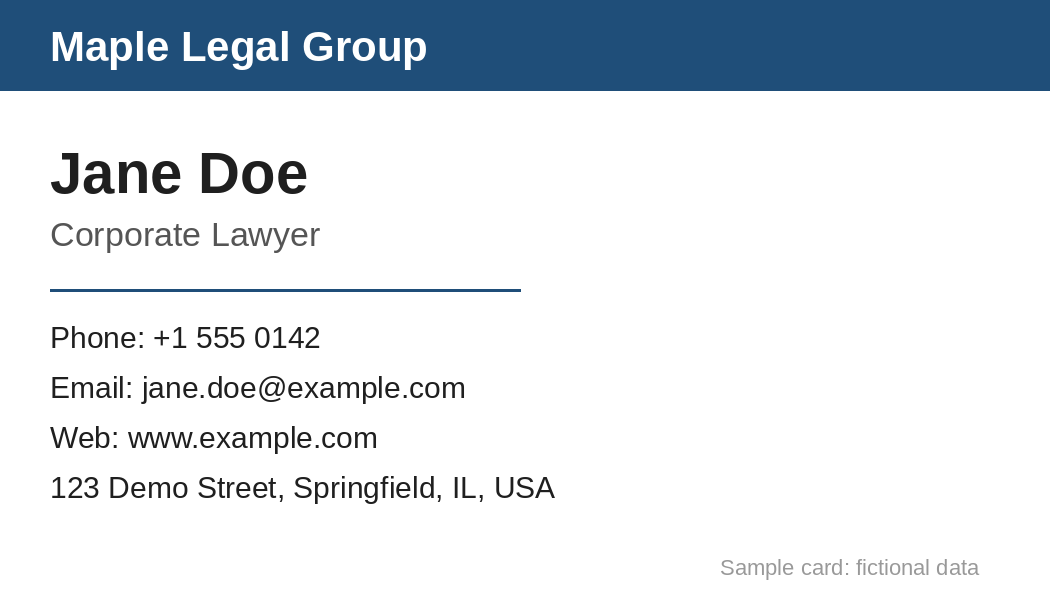

In [6]:
from PIL import Image, ImageDraw, ImageFont

# данные визитки — это же наш "ground truth" для проверки агента
card = {
    "name": "Jane Doe",
    "title": "Corporate Lawyer",
    "company": "Maple Legal Group",
    "phone": "+1 555 0142",
    "email": "jane.doe@example.com",
    "website": "www.example.com",
    "address": "123 Demo Street, Springfield, IL, USA",
}

def font(size, bold=False):
    name = "LiberationSans-Bold.ttf" if bold else "LiberationSans-Regular.ttf"
    try:
        return ImageFont.truetype(f"/usr/share/fonts/truetype/liberation/{name}", size)
    except OSError:
        return ImageFont.load_default(size=size)

# рисуем визитку
W, H = 1050, 600
img = Image.new("RGB", (W, H), "white")
draw = ImageDraw.Draw(img)
draw.rectangle([0, 0, W, 90], fill="#1f4e79")
draw.text((50, 22), card["company"], font=font(42, True), fill="white")
draw.text((50, 140), card["name"], font=font(58, True), fill="#1f1f1f")
draw.text((50, 215), card["title"], font=font(34), fill="#555555")
draw.line([(50, 290), (520, 290)], fill="#1f4e79", width=3)
draw.text((50, 320), f"Phone: {card['phone']}", font=font(30), fill="#1f1f1f")
draw.text((50, 370), f"Email: {card['email']}", font=font(30), fill="#1f1f1f")
draw.text((50, 420), f"Web: {card['website']}", font=font(30), fill="#1f1f1f")
draw.text((50, 470), card["address"], font=font(30), fill="#1f1f1f")
draw.text((W - 330, H - 45), "Sample card: fictional data", font=font(22), fill="#999999")

img.save("business_card.png")   # агенту нужен путь к файлу
display(img)

In [8]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

response = llm.invoke("Say hello in one short sentence.")
print(response.text)

Hello and welcome!


In [9]:
import base64
from langchain_core.messages import HumanMessage

def extract_text(img_path: str) -> str:
    """
    Extract all text from a business card image using a multimodal model.

    Args:
        img_path: A local image file path (string).

    Returns:
        The extracted text from the image.
    """
    try:
        # читаем картинку и превращаем её в base64-текст
        with open(img_path, "rb") as image_file:
            image_base64 = base64.b64encode(image_file.read()).decode("utf-8")

        # сообщение модели: инструкция + сама картинка
        message = [
            HumanMessage(
                content=[
                    {"type": "text",
                     "text": "Extract all the text from this business card image. Return only the extracted text, no explanations."},
                    {"type": "image_url",
                     "image_url": {"url": f"data:image/png;base64,{image_base64}"}},
                ]
            )
        ]

        response = llm.invoke(message)
        return response.text.strip()

    except Exception as e:
        print(f"Error extracting text: {e}")
        return ""

# проверка на нашей визитке
print(extract_text("business_card.png"))

Maple Legal Group

Jane Doe
Corporate Lawyer

Phone: +1 555 0142
Email: jane.doe@example.com
Web: www.example.com
123 Demo Street, Springfield, IL, USA

Sample card: fictional data


In [10]:
import csv
import os

CONTACTS_FILE = "contacts.csv"
FIELDS = ["name", "title", "company", "phone", "email", "website", "address"]

def save_contact(name: str, title: str, company: str, phone: str, email: str,
                 website: str = "", address: str = "") -> str:
    """
    Save a contact from a business card to the contacts CSV file.

    Args:
        name: Full name of the person.
        title: Job title.
        company: Company name.
        phone: Phone number.
        email: Email address.
        website: Website (optional).
        address: Postal address (optional).

    Returns:
        A confirmation message.
    """
    file_exists = os.path.exists(CONTACTS_FILE)

    with open(CONTACTS_FILE, "a", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=FIELDS)
        if not file_exists:
            writer.writeheader()          # заголовок пишем только один раз
        writer.writerow({
            "name": name, "title": title, "company": company,
            "phone": phone, "email": email,
            "website": website, "address": address,
        })

    return f"Contact saved: {name} ({email})"


# проверка без агента: сохраняем наш эталонный card
print(save_contact(**card))
print(open(CONTACTS_FILE, encoding="utf-8").read())

# удаляем тестовый файл, чтобы агент потом начал с чистого листа
os.remove(CONTACTS_FILE)

Contact saved: Jane Doe (jane.doe@example.com)
name,title,company,phone,email,website,address
Jane Doe,Corporate Lawyer,Maple Legal Group,+1 555 0142,jane.doe@example.com,www.example.com,"123 Demo Street, Springfield, IL, USA"



In [11]:
from typing import TypedDict, Annotated, Optional
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

# 1. список tools агента
tools = [extract_text, save_contact]

# 2. привязываем tools к модели
llm_with_tools = llm.bind_tools(tools)

# 3. State — общая память агента
class AgentState(TypedDict):
    input_file: Optional[str]                              # путь к картинке визитки
    messages: Annotated[list[AnyMessage], add_messages]    # история сообщений

print("Tools:", [t.__name__ for t in tools])

Tools: ['extract_text', 'save_contact']


In [12]:
from langchain_core.messages import SystemMessage

def assistant(state: AgentState):
    image = state["input_file"]

    # инструкция для агента (system prompt)
    sys_msg = SystemMessage(content=f"""
You are a helpful Business Card assistant.

Rules:
- If a business card image is provided, first use the extract_text tool to read it.
- Then use the save_contact tool to save the contact. Pass each field separately: name, title, company, phone, email, website, address.
- Copy the values exactly as they appear on the card. Never invent or guess missing data. If a field is missing, pass an empty string.
- Ignore text that is not contact data (for example notes like "Sample card").
- After saving, reply shortly: confirm the contact was saved and list the saved fields.

Currently loaded business card image: {image}
""")

    # отправляем модели инструкцию + всю историю сообщений
    response = llm_with_tools.invoke([sys_msg] + state["messages"])

    return {"messages": [response], "input_file": state["input_file"]}

print("assistant node ready")

assistant node ready


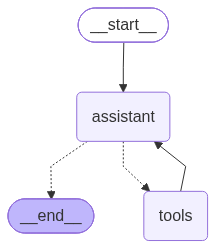

In [13]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display

# 1. граф с нашей памятью (State)
builder = StateGraph(AgentState)

# 2. nodes
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# 3. edges
builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant", tools_condition)
builder.add_edge("tools", "assistant")

# 4. компилируем
react_graph = builder.compile()

# 5. рисуем схему
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [14]:
question = "Please read this business card and save the contact."

result = react_graph.invoke({
    "messages": [HumanMessage(content=question)],
    "input_file": "business_card.png",
})

# весь ход рассуждений агента
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Please read this business card and save the contact.
================================== Ai Message ==================================

[]
Tool Calls:
  extract_text (call_551214)
 Call ID: call_551214
  Args:
    img_path: business_card.png
================================= Tool Message =================================
Name: extract_text

Maple Legal Group

Jane Doe
Corporate Lawyer

Phone: +1 555 0142
Email: jane.doe@example.com
Web: www.example.com
123 Demo Street, Springfield, IL, USA

Sample card: fictional data
================================== Ai Message ==================================

[]
Tool Calls:
  save_contact (call_743754)
 Call ID: call_743754
  Args:
    company: Maple Legal Group
    name: Jane Doe
    address: 123 Demo Street, Springfield, IL, USA
    title: Corporate Lawyer
    website: www.example.com
    email: jane.doe@example.com
    phone: +1 555 0142
==========================

In [15]:
import pandas as pd

# финальный ответ агента — чистым текстом
print(result["messages"][-1].text)

# что агент реально записал в CSV
display(pd.read_csv(CONTACTS_FILE))

The contact has been successfully saved with the following details:
- **Name:** Jane Doe
- **Title:** Corporate Lawyer
- **Company:** Maple Legal Group
- **Phone:** +1 555 0142
- **Email:** jane.doe@example.com
- **Website:** www.example.com
- **Address:** 123 Demo Street, Springfield, IL, USA


,name,title,company,phone,email,website,address
0,Jane Doe,Corporate Lawyer,Maple Legal Group,+1 555 0142,jane.doe@example.com,www.example.com,"123 Demo Street, Springfield, IL, USA"


In [16]:
# читаем сохранённый контакт (dtype=str — всё как текст, чтобы телефон не превратился в число)
saved = pd.read_csv(CONTACTS_FILE, dtype=str).iloc[0].to_dict()

correct = 0
for field in FIELDS:
    ok = saved[field] == card[field]
    correct += ok
    print(f"{'✅' if ok else '❌'} {field}: {saved[field]}")

print(f"\nAccuracy: {correct}/{len(FIELDS)} fields correct")

✅ name: Jane Doe
✅ title: Corporate Lawyer
✅ company: Maple Legal Group
✅ phone: +1 555 0142
✅ email: jane.doe@example.com
✅ website: www.example.com
✅ address: 123 Demo Street, Springfield, IL, USA

Accuracy: 7/7 fields correct
